<a href="https://colab.research.google.com/github/edaska/Stochastic_Processes_-_Optimization_in_Machine_Learning/blob/main/lab3/Stochastic_Processes_%26_Optimization_in_Machine_Learning_(Lab_3_Exercise_2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1><b>Exercise 2</b></h1> <p align="justify">A stochastic probability matrix P of a Markov chain is shown below. Some entries have been omitted:</p> <img src="https://raw.githubusercontent.com/netmode/Stochastic-Processes-and-Optimization-in-Machine-Learning-Lab/refs/heads/main/lab3/ex2.PNG"><img> <ul> <li>Complete the missing entries of the probability matrix P of the Markov chain.</li> <li>Using the <a href="http://setosa.io/markov/index.html#%7B%22tm%22%3A%5B%5B0.6%2C0.2%2C0%2C0%2C0%2C0.2%5D%2C%5B0.2%2C0.6%2C0.2%2C0%2C0%2C0%5D%2C%5B0%2C0.2%2C0.6%2C0.2%2C0%2C0%5D%2C%5B0%2C0%2C0.2%2C0.6%2C0.2%2C0%5D%2C%5B0%2C0%2C0%2C0.2%2C0.6%2C0.2%5D%2C%5B0.2%2C0%2C0%2C0%2C0.2%2C0.6%5D%5D%7D">simulator</a>, draw the above Markov chain and classify its states into communication classes. How this chain is called (based on its communication classes)? Based on this result, does the Markov chain have a stationary distribution?</li> <li>Using the code provided at the end of the exercise, estimate the stationary distribution of the Markov chain using the simulation method. The program: (a) defines the probability matrix and the initial distribution of the chain, (b) defines its model, and (c) estimates the stationary distribution of the chain for each state by dividing the number of visits to that state by the total number of steps of the chain (parameter <i>total_runs</i>). The program outputs a bar chart depicting the stationary distribution of the chain. Run the program for a total number of chain steps equal to (a) 500, (b) 1,000, (c) 10,000, (d) 100,000, (e) 1,000,000, (f) 10,000,000, and (g) 100,000,000. How much does the stationary distribution change between each run? How does the total execution time of the simulation change as the total number of chain steps increases? In your opinion, which total number of chain steps provides a good balance between the accuracy of the estimated result and the time required to run the simulation? <b>In order to run the program, you need to load the file <i><a href="https://github.com/netmode/Stochastic-Processes-and-Optimization-in-Machine-Learning-Lab/blob/main/lab3/simple_markov_chain_lib.py">simple_markov_chain_lib.py</a></i>.</b></li> <li>What do you observe about the stationary distribution values of the above Markov chain? Then compute the sum of the elements in each column of the probability matrix <b>P</b>. What is this kind of probability matrix called, and what property does the stationary distribution of such a chain have?</li>


The transition matrix $P$ for the Markov chain is defined as follows:

In [11]:
import numpy as np

P = np.array([
    [0.6,   0.2, 0, 0, 0,   0.2],
    [0.2, 0.6, 0.2, 0, 0, 0],
    [0, 0.2, 0.6, 0.2, 0, 0],
    [0, 0, 0.2, 0.6, 0.2, 0],
    [0, 0, 0, 0.2, 0.6, 0.2],
    [0.2, 0, 0, 0, 0.2, 0.6]
])

print(P)


print(f"\nEach row should sum to 1:\n {P.sum(axis=1, keepdims=True)}")

[[0.6 0.2 0.  0.  0.  0.2]
 [0.2 0.6 0.2 0.  0.  0. ]
 [0.  0.2 0.6 0.2 0.  0. ]
 [0.  0.  0.2 0.6 0.2 0. ]
 [0.  0.  0.  0.2 0.6 0.2]
 [0.2 0.  0.  0.  0.2 0.6]]

Each row should sum to 1:
 [[1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]]


The simulator graph shows that each state has a self-loop and is connected to its two neighboring states, forming a circular chain. From every state, it is possible to reach every other state in a finite number of steps, and vice versa. Therefore, all six states communicate with each other. Hence, the Markov chain has a single communication class:
{A,B,C,D,E,F} so the chain is irreducible.

The chain is called irreducible if all states belong to the same communication class, meaning every state can reach every other state in some finite number of steps with positive probability.

Yes,since it is a finite irreducible Markov chain, it has a stationary distribution. A stationary distribution is a probability vector π such that $πP=π$. This means that if the Markov chain starts with distribution π, then after one transition the distribution remains unchanged. In this example, because the chain is symmetric and all six states have the same transition structure, the stationary distribution is uniform:
$π = (\frac{1}{6},\frac{1}{6},\frac{1}{6},\frac{1}{6},\frac{1}{6},\frac{1}{6})$

Indeed, this vector satisfies $πP=π$, so it is the stationary distribution of the chain.

--2026-03-13 10:41:33--  https://raw.githubusercontent.com/netmode/Stochastic-Processes-and-Optimization-in-Machine-Learning-Lab/main/lab3/simple_markov_chain_lib.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4724 (4.6K) [text/plain]
Saving to: ‘simple_markov_chain_lib.py’

simple_markov_chain 100%[===================>]   4.61K  --.-KB/s    in 0s      

2026-03-13 10:41:33 (47.1 MB/s) - ‘simple_markov_chain_lib.py’ saved [4724/4724]

0:  0.1751
1:  0.1722
2:  0.1804
3:  0.1659
4:  0.1452
5:  0.1612


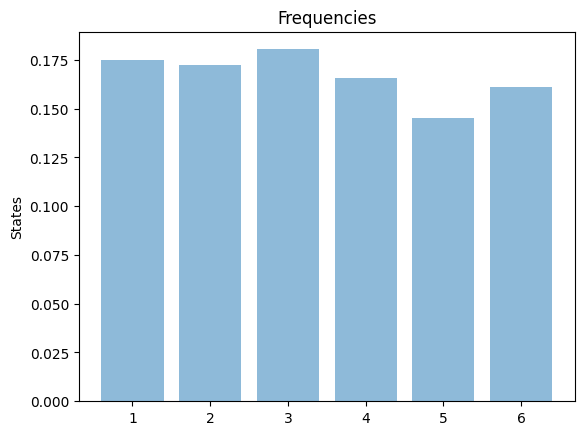

In [2]:
!wget https://raw.githubusercontent.com/netmode/Stochastic-Processes-and-Optimization-in-Machine-Learning-Lab/main/lab3/simple_markov_chain_lib.py -O simple_markov_chain_lib.py

from __future__ import division
from simple_markov_chain_lib import markov_chain
import numpy as np
import matplotlib.pyplot as plt

def defineMarkovTable():
	markov_table = {
		0: {0: 0.6, 1: 0.2, 5: 0.2},
		1: {0: 0.2, 1: 0.6, 2: 0.2},
		2: {1: 0.2, 2: 0.6, 3: 0.2},
		3: {2: 0.2, 3: 0.6, 4: 0.2},
		4: {3: 0.2, 4: 0.6, 5: 0.2},
		5: {0: 0.2, 4: 0.2, 5: 0.6}
        }

	return markov_table

def defineInitDistribution():
	init_dist = {0: 1.}

	return init_dist

def calculateFrequencyTable(markov_table,init_dist):
	total_runs = 10000

	visits = list()
	visits = [0] * len(markov_table)

	for index in range(total_runs):
		mc.move()
		visits[mc.running_state] += 1

	frequency = [v/total_runs for v in visits]

	return frequency

def printFrequencies(frequency, markov_table):
	for state in range(0, len(markov_table)) :
		print(str(state) + ": ", str(frequency[state]))

	return None

def plotFrequencies(frequency):
	objects = ('1', '2', '3', '4', '5', '6')
	y_pos = np.arange(len(objects))

	plt.bar(y_pos, frequency, align='center', alpha=0.5)
	plt.xticks(y_pos, objects)
	plt.ylabel('States')
	plt.title('Frequencies')
	plt.show()

	return None

if __name__ == "__main__":
	markov_table = defineMarkovTable()
	init_dist = defineInitDistribution()
	mc = markov_chain(markov_table, init_dist)
	mc.start()

	frequency = calculateFrequencyTable(markov_table, init_dist)
	printFrequencies(frequency, markov_table)
	plotFrequencies(frequency)

0:  0.196
1:  0.1
2:  0.154
3:  0.146
4:  0.202
5:  0.202


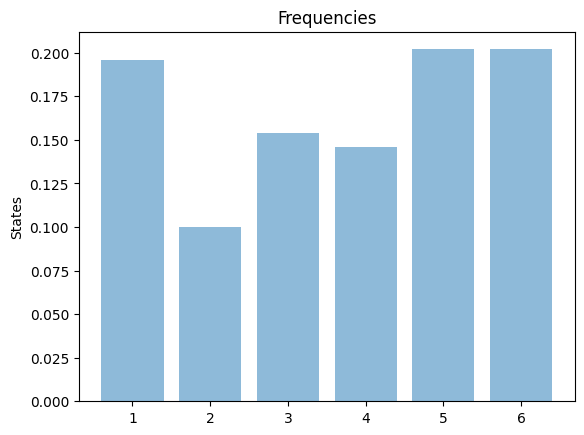

In [3]:
# (a) 500 steps

def defineMarkovTable():
	markov_table = {
		0: {0: 0.6, 1: 0.2, 5: 0.2},
		1: {0: 0.2, 1: 0.6, 2: 0.2},
		2: {1: 0.2, 2: 0.6, 3: 0.2},
		3: {2: 0.2, 3: 0.6, 4: 0.2},
		4: {3: 0.2, 4: 0.6, 5: 0.2},
		5: {0: 0.2, 4: 0.2, 5: 0.6}
        }

	return markov_table

def defineInitDistribution():
	init_dist = {0: 1.}

	return init_dist

def calculateFrequencyTable(markov_table,init_dist):
	total_runs = 500

	visits = list()
	visits = [0] * len(markov_table)

	for index in range(total_runs):
		mc.move()
		visits[mc.running_state] += 1

	frequency = [v/total_runs for v in visits]

	return frequency

def printFrequencies(frequency, markov_table):
	for state in range(0, len(markov_table)) :
		print(str(state) + ": ", str(frequency[state]))

	return None

def plotFrequencies(frequency):
	objects = ('1', '2', '3', '4', '5', '6')
	y_pos = np.arange(len(objects))

	plt.bar(y_pos, frequency, align='center', alpha=0.5)
	plt.xticks(y_pos, objects)
	plt.ylabel('States')
	plt.title('Frequencies')
	plt.show()

	return None

if __name__ == "__main__":
	markov_table = defineMarkovTable()
	init_dist = defineInitDistribution()
	mc = markov_chain(markov_table, init_dist)
	mc.start()

	frequency = calculateFrequencyTable(markov_table, init_dist)
	printFrequencies(frequency, markov_table)
	plotFrequencies(frequency)

0:  0.11
1:  0.174
2:  0.182
3:  0.209
4:  0.194
5:  0.131


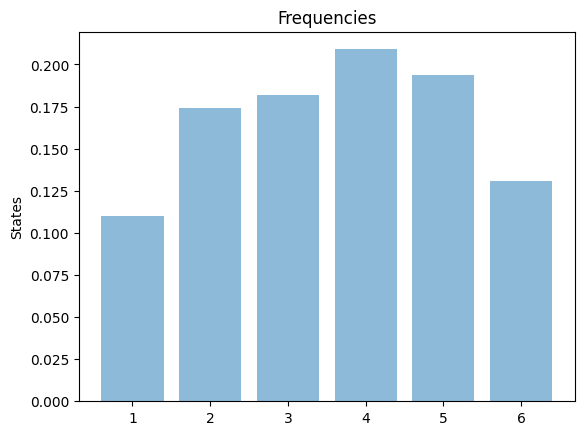

In [4]:
# (b) 1000 steps

def defineMarkovTable():
	markov_table = {
		0: {0: 0.6, 1: 0.2, 5: 0.2},
		1: {0: 0.2, 1: 0.6, 2: 0.2},
		2: {1: 0.2, 2: 0.6, 3: 0.2},
		3: {2: 0.2, 3: 0.6, 4: 0.2},
		4: {3: 0.2, 4: 0.6, 5: 0.2},
		5: {0: 0.2, 4: 0.2, 5: 0.6}
        }

	return markov_table

def defineInitDistribution():
	init_dist = {0: 1.}

	return init_dist

def calculateFrequencyTable(markov_table,init_dist):
	total_runs = 1000

	visits = list()
	visits = [0] * len(markov_table)

	for index in range(total_runs):
		mc.move()
		visits[mc.running_state] += 1

	frequency = [v/total_runs for v in visits]

	return frequency

def printFrequencies(frequency, markov_table):
	for state in range(0, len(markov_table)) :
		print(str(state) + ": ", str(frequency[state]))

	return None

def plotFrequencies(frequency):
	objects = ('1', '2', '3', '4', '5', '6')
	y_pos = np.arange(len(objects))

	plt.bar(y_pos, frequency, align='center', alpha=0.5)
	plt.xticks(y_pos, objects)
	plt.ylabel('States')
	plt.title('Frequencies')
	plt.show()

	return None

if __name__ == "__main__":
	markov_table = defineMarkovTable()
	init_dist = defineInitDistribution()
	mc = markov_chain(markov_table, init_dist)
	mc.start()

	frequency = calculateFrequencyTable(markov_table, init_dist)
	printFrequencies(frequency, markov_table)
	plotFrequencies(frequency)

0:  0.16397
1:  0.16762
2:  0.16762
3:  0.16652
4:  0.16782
5:  0.16645


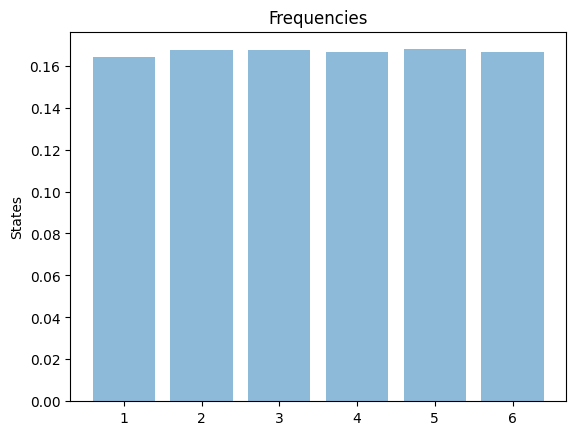

In [5]:
# (d) 100.000 steps

def defineMarkovTable():
	markov_table = {
		0: {0: 0.6, 1: 0.2, 5: 0.2},
		1: {0: 0.2, 1: 0.6, 2: 0.2},
		2: {1: 0.2, 2: 0.6, 3: 0.2},
		3: {2: 0.2, 3: 0.6, 4: 0.2},
		4: {3: 0.2, 4: 0.6, 5: 0.2},
		5: {0: 0.2, 4: 0.2, 5: 0.6}
        }

	return markov_table

def defineInitDistribution():
	init_dist = {0: 1.}

	return init_dist

def calculateFrequencyTable(markov_table,init_dist):
	total_runs = 100000

	visits = list()
	visits = [0] * len(markov_table)

	for index in range(total_runs):
		mc.move()
		visits[mc.running_state] += 1

	frequency = [v/total_runs for v in visits]

	return frequency

def printFrequencies(frequency, markov_table):
	for state in range(0, len(markov_table)) :
		print(str(state) + ": ", str(frequency[state]))

	return None

def plotFrequencies(frequency):
	objects = ('1', '2', '3', '4', '5', '6')
	y_pos = np.arange(len(objects))

	plt.bar(y_pos, frequency, align='center', alpha=0.5)
	plt.xticks(y_pos, objects)
	plt.ylabel('States')
	plt.title('Frequencies')
	plt.show()

	return None

if __name__ == "__main__":
	markov_table = defineMarkovTable()
	init_dist = defineInitDistribution()
	mc = markov_chain(markov_table, init_dist)
	mc.start()

	frequency = calculateFrequencyTable(markov_table, init_dist)
	printFrequencies(frequency, markov_table)
	plotFrequencies(frequency)

0:  0.165137
1:  0.166069
2:  0.168307
3:  0.167471
4:  0.167961
5:  0.165055


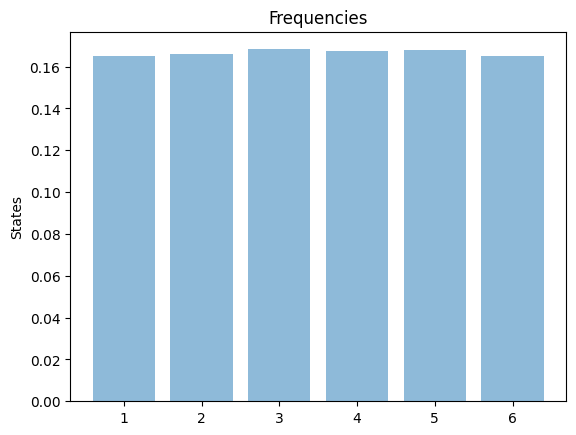

In [6]:
# (e) 1,000,000 steps

def defineMarkovTable():
	markov_table = {
		0: {0: 0.6, 1: 0.2, 5: 0.2},
		1: {0: 0.2, 1: 0.6, 2: 0.2},
		2: {1: 0.2, 2: 0.6, 3: 0.2},
		3: {2: 0.2, 3: 0.6, 4: 0.2},
		4: {3: 0.2, 4: 0.6, 5: 0.2},
		5: {0: 0.2, 4: 0.2, 5: 0.6}
        }

	return markov_table

def defineInitDistribution():
	init_dist = {0: 1.}

	return init_dist

def calculateFrequencyTable(markov_table,init_dist):
	total_runs = 1000000

	visits = list()
	visits = [0] * len(markov_table)

	for index in range(total_runs):
		mc.move()
		visits[mc.running_state] += 1

	frequency = [v/total_runs for v in visits]

	return frequency

def printFrequencies(frequency, markov_table):
	for state in range(0, len(markov_table)) :
		print(str(state) + ": ", str(frequency[state]))

	return None

def plotFrequencies(frequency):
	objects = ('1', '2', '3', '4', '5', '6')
	y_pos = np.arange(len(objects))

	plt.bar(y_pos, frequency, align='center', alpha=0.5)
	plt.xticks(y_pos, objects)
	plt.ylabel('States')
	plt.title('Frequencies')
	plt.show()

	return None

if __name__ == "__main__":
	markov_table = defineMarkovTable()
	init_dist = defineInitDistribution()
	mc = markov_chain(markov_table, init_dist)
	mc.start()

	frequency = calculateFrequencyTable(markov_table, init_dist)
	printFrequencies(frequency, markov_table)
	plotFrequencies(frequency)

0:  0.1665113
1:  0.1667065
2:  0.1668154
3:  0.1667595
4:  0.1666262
5:  0.1665811


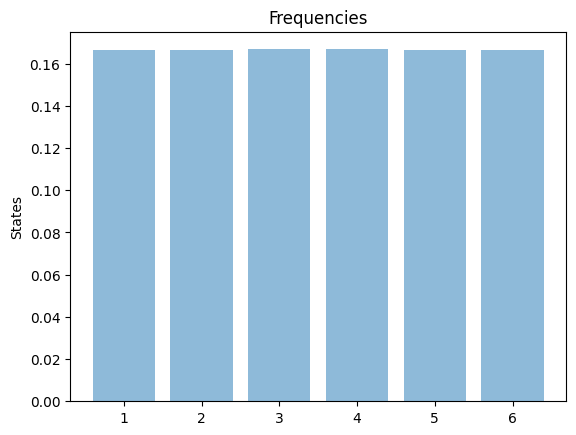

In [7]:
# (f) 10,000,000 steps

def defineMarkovTable():
	markov_table = {
		0: {0: 0.6, 1: 0.2, 5: 0.2},
		1: {0: 0.2, 1: 0.6, 2: 0.2},
		2: {1: 0.2, 2: 0.6, 3: 0.2},
		3: {2: 0.2, 3: 0.6, 4: 0.2},
		4: {3: 0.2, 4: 0.6, 5: 0.2},
		5: {0: 0.2, 4: 0.2, 5: 0.6}
        }

	return markov_table

def defineInitDistribution():
	init_dist = {0: 1.}

	return init_dist

def calculateFrequencyTable(markov_table,init_dist):
	total_runs = 10000000

	visits = list()
	visits = [0] * len(markov_table)

	for index in range(total_runs):
		mc.move()
		visits[mc.running_state] += 1

	frequency = [v/total_runs for v in visits]

	return frequency

def printFrequencies(frequency, markov_table):
	for state in range(0, len(markov_table)) :
		print(str(state) + ": ", str(frequency[state]))

	return None

def plotFrequencies(frequency):
	objects = ('1', '2', '3', '4', '5', '6')
	y_pos = np.arange(len(objects))

	plt.bar(y_pos, frequency, align='center', alpha=0.5)
	plt.xticks(y_pos, objects)
	plt.ylabel('States')
	plt.title('Frequencies')
	plt.show()

	return None

if __name__ == "__main__":
	markov_table = defineMarkovTable()
	init_dist = defineInitDistribution()
	mc = markov_chain(markov_table, init_dist)
	mc.start()

	frequency = calculateFrequencyTable(markov_table, init_dist)
	printFrequencies(frequency, markov_table)
	plotFrequencies(frequency)

0:  0.16656862
1:  0.16656335
2:  0.16665476
3:  0.16671601
4:  0.16673915
5:  0.16675811


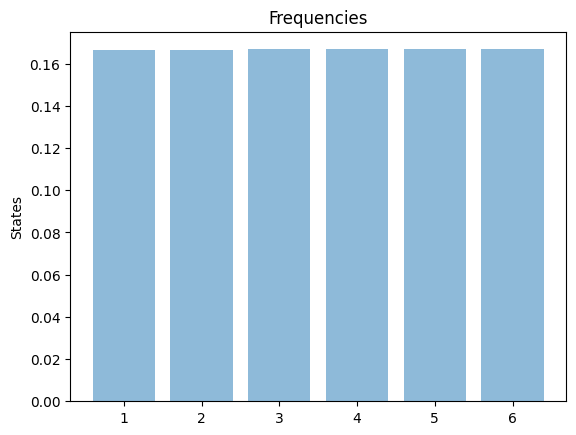

In [8]:
# (g) 100,000,000 steps

def defineMarkovTable():
	markov_table = {
		0: {0: 0.6, 1: 0.2, 5: 0.2},
		1: {0: 0.2, 1: 0.6, 2: 0.2},
		2: {1: 0.2, 2: 0.6, 3: 0.2},
		3: {2: 0.2, 3: 0.6, 4: 0.2},
		4: {3: 0.2, 4: 0.6, 5: 0.2},
		5: {0: 0.2, 4: 0.2, 5: 0.6}
        }

	return markov_table

def defineInitDistribution():
	init_dist = {0: 1.}

	return init_dist

def calculateFrequencyTable(markov_table,init_dist):
	total_runs = 100000000

	visits = list()
	visits = [0] * len(markov_table)

	for index in range(total_runs):
		mc.move()
		visits[mc.running_state] += 1

	frequency = [v/total_runs for v in visits]

	return frequency

def printFrequencies(frequency, markov_table):
	for state in range(0, len(markov_table)) :
		print(str(state) + ": ", str(frequency[state]))

	return None

def plotFrequencies(frequency):
	objects = ('1', '2', '3', '4', '5', '6')
	y_pos = np.arange(len(objects))

	plt.bar(y_pos, frequency, align='center', alpha=0.5)
	plt.xticks(y_pos, objects)
	plt.ylabel('States')
	plt.title('Frequencies')
	plt.show()

	return None

if __name__ == "__main__":
	markov_table = defineMarkovTable()
	init_dist = defineInitDistribution()
	mc = markov_chain(markov_table, init_dist)
	mc.start()

	frequency = calculateFrequencyTable(markov_table, init_dist)
	printFrequencies(frequency, markov_table)
	plotFrequencies(frequency)

*How much does the stationary distribution change between each run?*

The estimated stationary distribution becomes more stable as the number of steps increases. For a small number of steps, there are larger fluctuations in the estimated state frequencies. As the number of steps grows, these fluctuations decrease and the distribution converges to the theoretical stationary distribution.

*How does the total execution time of the simulation change as the total number of chain steps increases?*

The total execution time increases with the number of chain steps, since a larger number of simulated transitions requires more computations.

*In your opinion, which total number of chain steps provides a good balance between the accuracy of the estimated result and the time required to run the simulation?*

I believe that 1,000,000 steps provide a good balance between the accuracy of the estimated stationary distribution and the time needed to run the simulation. At this number of steps, the estimated probabilities are already very close to the theoretical stationary distribution, while the execution time is still reasonable. Using more steps gives only a very small improvement in accuracy, so it is not necessary to go much further.

*What do you observe about the stationary distribution values of the above Markov chain? Then compute the sum of the elements in each column of the probability matrix P. What is this kind of probability matrix called, and what property does the stationary distribution of such a chain have?*




A stationary distribution is a probability distribution over the states that stays unchanged after one step of the Markov chain.

So if $π = ({π}_{Α},{π}_{B},{π}_{C},{π}_{D},{π}_{E},{π}_{F})$ describes the probabilities of being in states A,B,C,D,E,F, then π is stationary if $πP=π$

That equation means that start with probabilities π, then if apply one transition of the chain, you will get the same probabilities back.
In our matrix each state:
*   stays where it is with probability 0.6
*   goes to the left neighbor with probability 0.2
*   goes to the right neighbor with probability 0.2

So the chain is perfectly symmetric.

That symmetry suggests that all states should have the same stationary probability.

So, we have $π = (\frac{1}{6},\frac{1}{6},\frac{1}{6},\frac{1}{6},\frac{1}{6},\frac{1}{6})$




In [19]:
import pandas as pd

P = np.array([
    [0.6,   0.2, 0, 0, 0,   0.2],
    [0.2, 0.6, 0.2, 0, 0, 0],
    [0, 0.2, 0.6, 0.2, 0, 0],
    [0, 0, 0.2, 0.6, 0.2, 0],
    [0, 0, 0, 0.2, 0.6, 0.2],
    [0.2, 0, 0, 0, 0.2, 0.6]
])

print(P)

df= pd.DataFrame(P)

sum_col = df.sum()

print(f"\n The sum of the elements in each column:\n {sum_col}")

[[0.6 0.2 0.  0.  0.  0.2]
 [0.2 0.6 0.2 0.  0.  0. ]
 [0.  0.2 0.6 0.2 0.  0. ]
 [0.  0.  0.2 0.6 0.2 0. ]
 [0.  0.  0.  0.2 0.6 0.2]
 [0.2 0.  0.  0.  0.2 0.6]]

 The sum of the elements in each column:
 0    1.0
1    1.0
2    1.0
3    1.0
4    1.0
5    1.0
dtype: float64


This kind of probability matrix is called a doubly stochastic matrix, because both its rows and its columns sum to 1. The stationary distribution of such a Markov chain has the property of being uniform over the state space. Therefore, if the chain has 6 states, the stationary distribution is $π = (\frac{1}{6},\frac{1}{6},\frac{1}{6},\frac{1}{6},\frac{1}{6},\frac{1}{6})$
